In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy.signal import find_peaks

In [2]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
INNER_NITRATE_PATH = (
    DATA_DIR
    / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2023-09-17_with_dndt_resampled.nc"
)
MIDSHELF_NITRATE_PATH = (
    DATA_DIR
    / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-07-14_with_dndt_resampled.nc"
)
WIND_PATH = DATA_DIR / "NDBC_46050/46050_wind_binned_with_w5d_w8d.nc"
OPTAA_PATH = DATA_DIR / "CE01ISSM/ce01issm_optaa_processed.nc"
FLORT_PATH = DATA_DIR / "CE01ISSM/ce01issm_flort_processed.nc"

In [3]:
inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
midshelf_nitrate = xr.open_dataset(MIDSHELF_NITRATE_PATH)
wind = xr.open_dataset(WIND_PATH, decode_timedelta=True)
optaa = xr.open_dataset(OPTAA_PATH)
flort = xr.open_dataset(FLORT_PATH)


flort = flort.drop_dims("stats")
optaa_al, flort_al = xr.align(
    optaa.drop_duplicates("time"), flort.drop_duplicates("time")
)

## Chlorophyll-Nitrate

Text(0.02, 0.5, 'Estimated Chlorophyll [$\\mathrm{mg \\; m^{-3} }$]')

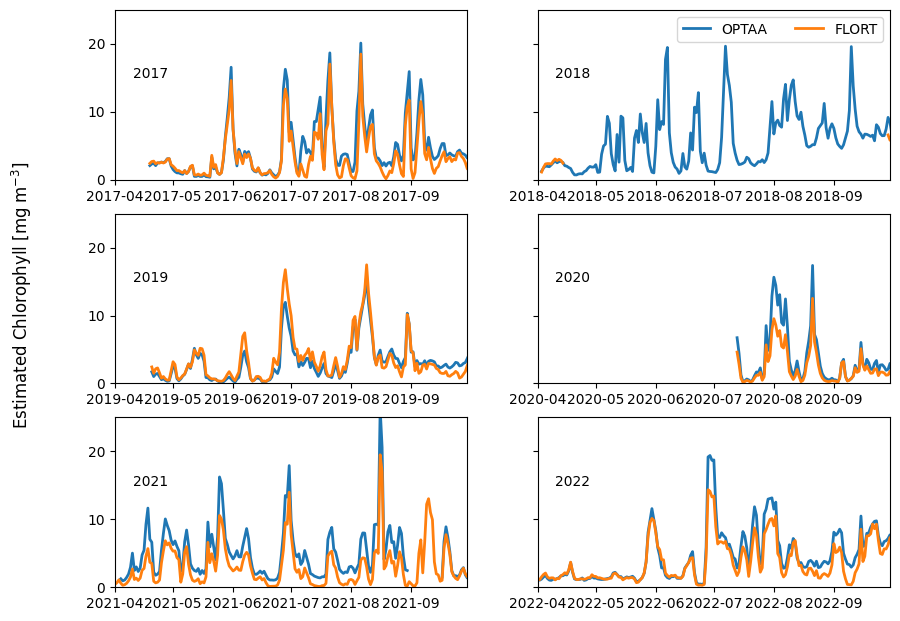

In [4]:
years = np.arange(np.datetime64("2017"), np.datetime64("2024"), np.timedelta64(1, "Y"))
# years_str = [str(year) for year in years]
fig, axs = plt.subplots((len(years) - 1) // 2, 2, figsize=(10, 7.5), sharey=True)
for i, (ts, te, ax) in enumerate(zip(years[:-1], years[1:], axs.flatten())):
    # print(ts, te)
    temp = optaa.where((optaa.time > ts) & (optaa.time < te), drop=True)
    temp = temp.sortby("time")
    temp = temp.resample(time="1D").mean()
    ax.plot(temp.time, temp.estimated_chlorophyll, linewidth=2, label="OPTAA")

    temp = flort.where((flort.time > ts) & (flort.time < te), drop=True)
    temp = temp.sortby("time")
    temp = temp.resample(time="1D").mean()
    ax.plot(temp.time, temp.estimated_chlorophyll, linewidth=2, label="FLORT")

    ax.set_xlim(
        [
            np.datetime64(f"{years[i]!s}-04-01"),
            np.datetime64(f"{years[i]!s}-09-30"),
        ]
    )
    ax.set_ylim([0, 25])
    ax.annotate(f"{ts}", xy=(0.05, 0.6), xytext=(0.05, 0.6), xycoords="axes fraction")


[ax.set_yticks([0, 10, 20]) for ax in axs.T[0]]


axs[0][1].legend(ncols=2)
fig.supylabel("Estimated Chlorophyll [$\\mathrm{mg \\; m^{-3} }$]")

C:\Users\asche\AppData\Local\Temp\ipykernel_36776\3230460961.py:15: RuntimeWarning: Mean of empty slice
  chloro = np.nanmean(


Text(0, 0.5, '7 meter\nChlorophyll [$\\mathsf{mg \\; m^{-3}}$]')

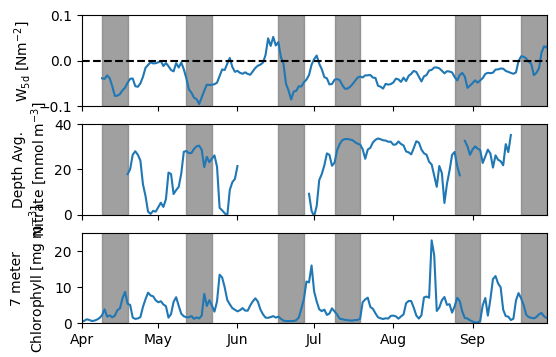

In [5]:
ts = np.datetime64("2021")
te = np.datetime64("2022")
temp1 = (
    flort.where((flort.time > ts) & (flort.time < te))
    .sortby("time")
    .resample(time="1D")
    .mean()
)
temp2 = (
    optaa.where((optaa.time > ts) & (optaa.time < te))
    .sortby("time")
    .resample(time="1D")
    .mean()
)
chloro = np.nanmean(
    [temp1.estimated_chlorophyll.values, temp2.estimated_chlorophyll.values], axis=0
)

fig, axs = plt.subplots(3, 1, figsize=(6, 4), sharex=True)
# [axs[0].axvline(cw.time.values[5], color='gray') for cw in composite_wind_events]

[
    axs[0].fill_betweenx(
        [-0.1, 0.1],
        wind["w5d"].time[idx - 5].values,
        wind["w5d"].time[idx + 5].values,
        color="gray",
        alpha=0.75,
    )
    for idx in find_peaks(-wind["w5d"], height=0.01, distance=20, prominence=0.01)[0]
]
[
    axs[1].fill_betweenx(
        [0, 40],
        wind["w5d"].time[idx - 5].values,
        wind["w5d"].time[idx + 5].values,
        color="gray",
        alpha=0.75,
    )
    for idx in find_peaks(-wind["w5d"], height=0.01, distance=20, prominence=0.01)[0]
]
[
    axs[2].fill_betweenx(
        [0, 30],
        wind["w5d"].time[idx - 5].values,
        wind["w5d"].time[idx + 5].values,
        color="gray",
        alpha=0.75,
    )
    for idx in find_peaks(-wind["w5d"], height=0.01, distance=20, prominence=0.01)[0]
]
axs[0].plot(wind.time, wind["w5d"])
axs[0].set_ylim(-0.1, 0.1)
axs[0].axhline(0, color="black", ls="--")
ln2 = axs[1].plot(
    inner_nitrate.time.resample(time="1D").mean(),
    inner_nitrate.nitrate.mean(dim="depth").resample(time="1D").mean(),
)
ln1 = axs[2].plot(temp1.time, chloro)
axs[1].set_ylim(0, 40)
axs[2].set_ylim(0, 25)
axs[2].set_xlim(np.datetime64(f"{ts!s}-04-01"), np.datetime64(f"{ts!s}-09-30"))
myFmt = mdates.DateFormatter("%b")
axs[2].xaxis.set_major_locator(mdates.MonthLocator())
axs[2].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

[ax.minorticks_off() for ax in axs]
axs[0].set_ylabel("$\\mathsf{W_{5d}}$ [$\\mathsf{N m^{-2}}$]")
axs[1].set_ylabel("Depth Avg.\nNitrate [$\\mathsf{mmol \\; m^{-3}}$]")
axs[2].set_ylabel("7 meter\nChlorophyll [$\\mathsf{mg \\; m^{-3}}$]")

C:\Users\asche\AppData\Local\Temp\ipykernel_36776\3846114940.py:15: RuntimeWarning: Mean of empty slice
  chloro = np.nanmean(


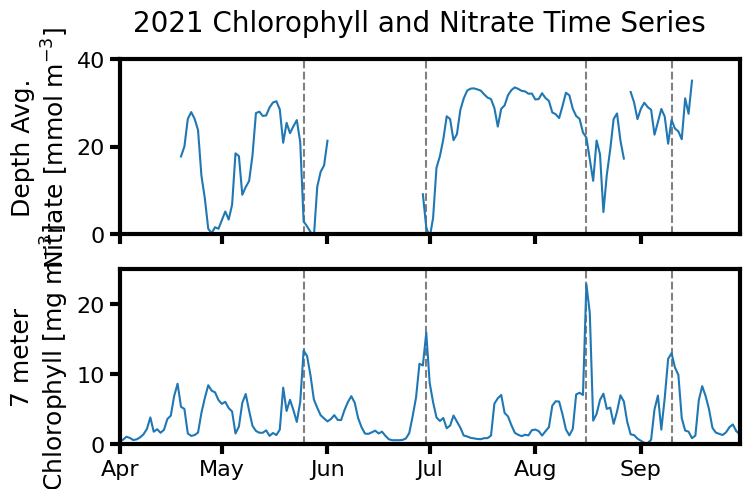

In [6]:
ts = np.datetime64("2021")
te = np.datetime64("2022")
temp1 = (
    flort.where((flort.time > ts) & (flort.time < te))
    .sortby("time")
    .resample(time="1D")
    .mean()
)
temp2 = (
    optaa.where((optaa.time > ts) & (optaa.time < te))
    .sortby("time")
    .resample(time="1D")
    .mean()
)
chloro = np.nanmean(
    [temp1.estimated_chlorophyll.values, temp2.estimated_chlorophyll.values], axis=0
)

fig, axs = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
plt.suptitle("2021 Chlorophyll and Nitrate Time Series", fontsize=20)
# [axs[0].axvline(cw.time.values[5], color='gray') for cw in composite_wind_events]
[
    axs[0].axvline(x.values, c="gray", ls="--")
    for x in temp1.time[find_peaks(chloro, height=5, distance=1, prominence=10)[0]]
]
[
    axs[1].axvline(x.values, c="gray", ls="--")
    for x in temp1.time[find_peaks(chloro, height=5, distance=1, prominence=10)[0]]
]
# [axs[2].axvline(x.values, c='gray', ls='--') for x in temp1.time[find_peaks(chloro, height=5, distance=1, prominence=10)[0]]]
# [axs[0].axvline(wind['w5d'].time[idx-5].values, wind['w5d'].time[idx+5].values, color='gray', alpha=0.75) for idx in find_peaks(-wind['w5d'], height=0.01, distance=20, prominence=0.01)[0]]
# [axs[1].fill_betweenx([0, 40], wind['w5d'].time[idx-5].values, wind['w5d'].time[idx+5].values, color='gray', alpha=0.75) for idx in find_peaks(-wind['w5d'], height=0.01, distance=20, prominence=0.01)[0]]
# [axs[2].fill_betweenx([0, 30], wind['w5d'].time[idx-5].values, wind['w5d'].time[idx+5].values, color='gray', alpha=0.75) for idx in find_peaks(-wind['w5d'], height=0.01, distance=20, prominence=0.01)[0]]
# axs[0].plot(wind.time, wind['coare_y'])
# axs[0].set_ylim(-0.1, 0.1)
# axs[0].axhline(0, color='black')
ln2 = axs[0].plot(
    inner_nitrate.time.resample(time="1D").mean(),
    inner_nitrate.nitrate.mean(dim="depth").resample(time="1D").mean(),
)
ln1 = axs[1].plot(temp1.time, chloro)
axs[0].set_ylim(0, 40)
axs[1].set_ylim(0, 25)
axs[1].set_xlim(np.datetime64(f"{ts!s}-04-01"), np.datetime64(f"{ts!s}-09-30"))
myFmt = mdates.DateFormatter("%b")
axs[1].xaxis.set_major_locator(mdates.MonthLocator())
axs[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

[ax.minorticks_off() for ax in axs]
# axs[0].set_ylabel('$\\mathsf{W_{5d}}$ [$\\mathsf{N m^{-2}}$]', fontsize=18)
axs[0].set_ylabel("Depth Avg.\nNitrate [$\\mathsf{mmol \\; m^{-3}}$]", fontsize=18)
axs[1].set_ylabel("7 meter\nChlorophyll [$\\mathsf{mg \\; m^{-3}}$]", fontsize=18)

[ax.tick_params(axis="both", width=3, size=7, labelsize=16) for ax in axs]
[ax.tick_params(axis="both", which="minor", width=2, size=5) for ax in axs]

for axis in ["top", "bottom", "left", "right"]:
    [ax.spines[axis].set_linewidth(3) for ax in axs]

# plt.savefig(
#     os.path.join(notebook_dir, "../manuscript/chlorophyll-nitrate-2021.pdf"),
#     format="pdf",
# )